## NMD Models: Synthetic Data Generation

This notebook generates a single consistent synthetic dataset used across **all NMD model notebooks**.

| Variable | Description | Used In |
|---|---|---|
| `balance` | Monthly deposit balance (MB) | All models |
| `deposit_rate` | Client deposit rate (%) | Deposit Rate, Economic Theory, Floor |
| `market_rate` | 10Y bond yield / market rate (%) | Deposit Rate, Economic Theory, Floor |
| `repo_rate` | Policy / repo rate (%) | Survival/Decay (MEV) |
| `unemployment` | Unemployment rate (%) | Survival/Decay (MEV) |
| `cds_spread` | Bank CDS spread (bps) | Economic Theory, Deposit Volume |
| `wealth` | Client wealth index | Wealth Allocation |
| `equity_return` | Equity index log-return (%) | Wealth Allocation |
| `equity_vol` | Equity implied volatility (VIX-like) | Wealth Allocation |

In [1]:
# Import libraries
import warnings
import numpy as np
import pandas as pd
import sys; sys.path.insert(0, "..")

from src.data_generator import generate_nmd_dataset
from src.plot_function import plot_nmd_data

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action ="ignore", category = pd.errors.PerformanceWarning)

In [2]:
# Global simulation parameters
N_MONTHS = 150 #~12.5 years of monthly observations
SEED = 42 #Random seed for reproducibility
START_DATE = "2012-01-31" #Start of observation window

# Ramdom generator
rng = np.random.default_rng(SEED)

In [3]:
# Generate dataset
df = generate_nmd_dataset(
    n_months = N_MONTHS,
    start_date = START_DATE,
    rng = rng
)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head(5)

Dataset shape: (150, 9)
Date range: 2012-01-31 to 2024-06-30


,balance,deposit_rate,market_rate,repo_rate,unemployment,cds_spread,wealth,equity_return,equity_vol
date,,,,,,,,,
2012-01-31,5000.000,0.011,0.055,0.025,0.045,55.000,1000.000,-0.000,0.180
2012-02-29,5088.121,0.011,0.048,0.021,0.043,53.617,1030.391,0.056,0.167
2012-03-31,5181.869,0.011,0.047,0.024,0.046,48.113,1020.081,-0.011,0.169
2012-04-30,5230.664,0.012,0.049,0.026,0.044,63.174,1046.073,0.045,0.156
2012-05-31,5340.819,0.010,0.043,0.022,0.042,77.784,1039.899,-0.018,0.124


In [4]:
# Descriptive Statistics
desc = df.describe().T
desc["unit"] = [
    "MB", "decimal", "decimal", "decimal",
    "decimal", "bps", "index", "decimal", "decimal"
]
desc[["unit", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(4)

,unit,mean,std,min,25%,50%,75%,max
balance,MB,17550.848,9853.118,5000.000,9264.115,15744.436,23576.707,41822.950
deposit_rate,decimal,0.009,0.002,0.004,0.008,0.009,0.010,0.013
market_rate,decimal,0.049,0.007,0.028,0.043,0.048,0.054,0.064
repo_rate,decimal,0.025,0.003,0.017,0.023,0.025,0.027,0.032
unemployment,decimal,0.036,0.006,0.021,0.030,0.036,0.041,0.048
cds_spread,bps,66.587,25.913,31.275,48.204,59.934,82.366,184.451
wealth,index,1618.037,350.070,1000.000,1283.208,1661.934,1901.144,2205.099
equity_return,decimal,0.005,0.035,-0.081,-0.018,0.002,0.028,0.103
equity_vol,decimal,0.175,0.027,0.090,0.159,0.179,0.193,0.242


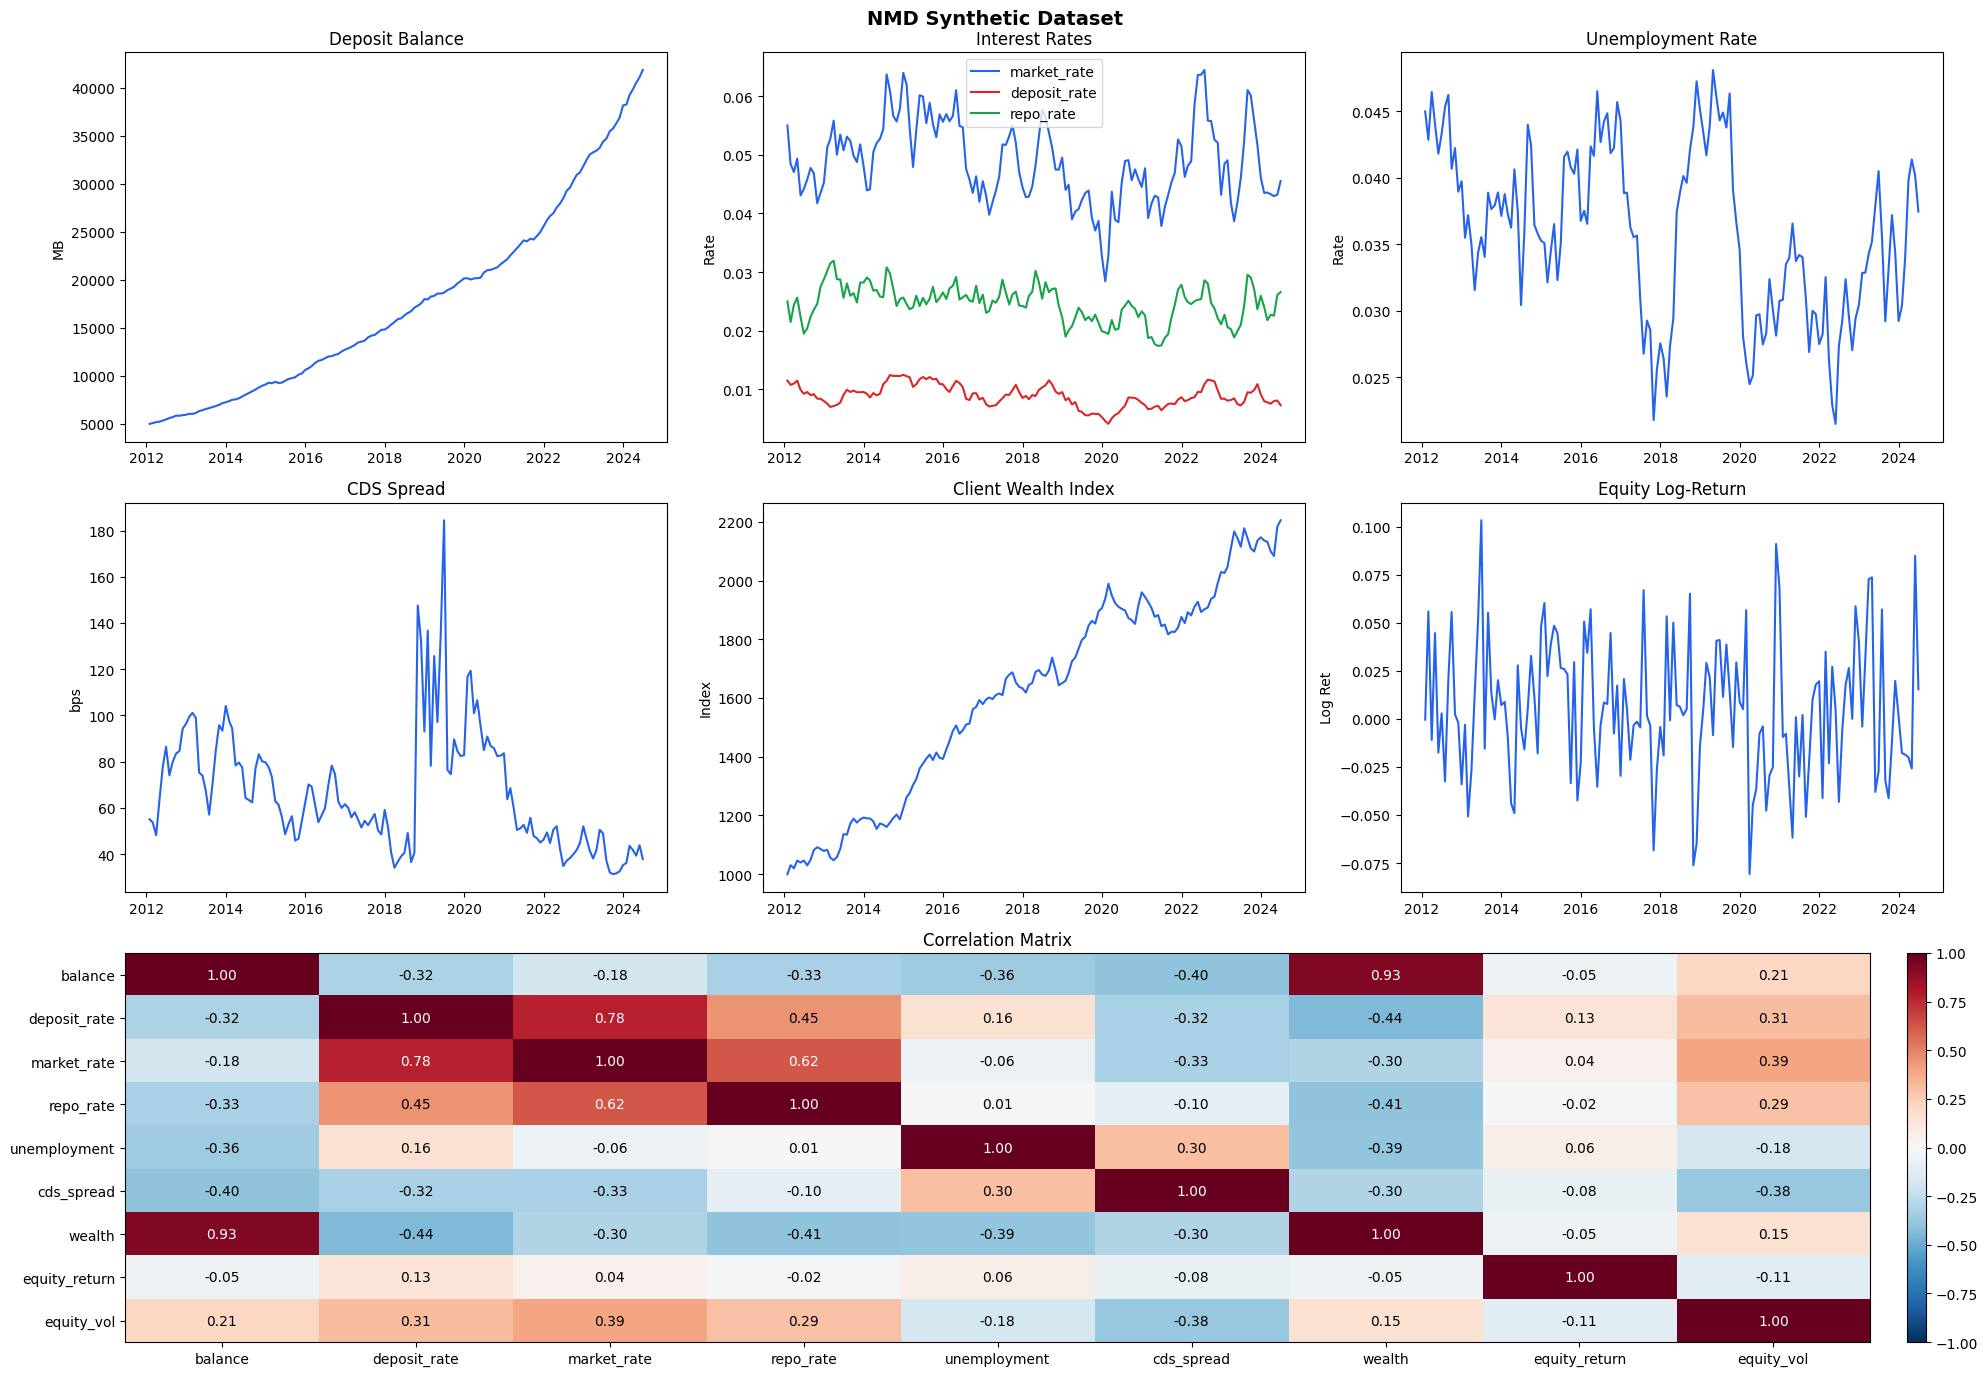

In [5]:
# Plot
plot_nmd_data(df)

In [6]:
# Export
df.to_parquet(
    "../data/raw/nmd_data.parquet",
    engine = "pyarrow"
)